<a href="https://colab.research.google.com/github/RayhanPradana/PCVK_Rayhan-Pradana/blob/main/PCVK_Modul_5_Rayhan_Pradana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import cv2
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
from math import log10, sqrt

Mengubah tingkat kecerahan citra dengan Gamma Correction
-------------------------------------------------------
Masukkan nilai gamma: 5


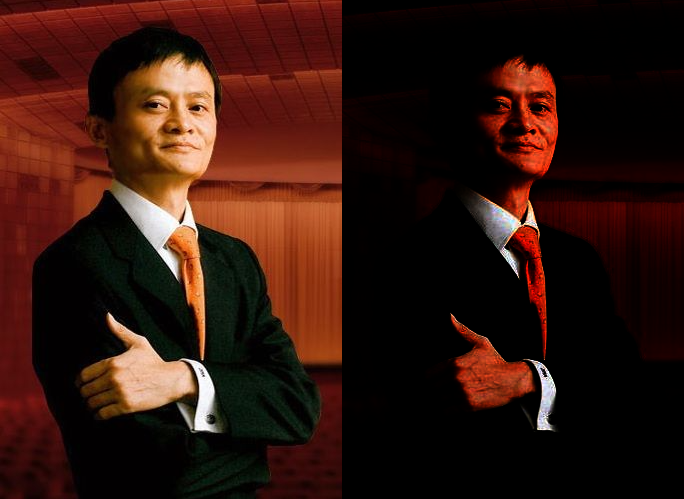

In [ ]:
print('Mengubah tingkat kecerahan citra dengan Gamma Correction')
print('-------------------------------------------------------')

try:
    gamma = int(input('Masukkan nilai gamma: '))
except ValueError:
    print('Error, bukan angka')

original = cv.imread('/content/drive/MyDrive/Bahan PCVK/man.png')

normalized = original / 255.0
gamma_corrected = np.power(normalized, gamma)
gamma_corrected = np.uint8(gamma_corrected * 255)

final_frame = cv.hconcat((original, gamma_corrected))
cv2_imshow(final_frame)

Mengubah gambar berdasarkan bit depth
-------------------------------------


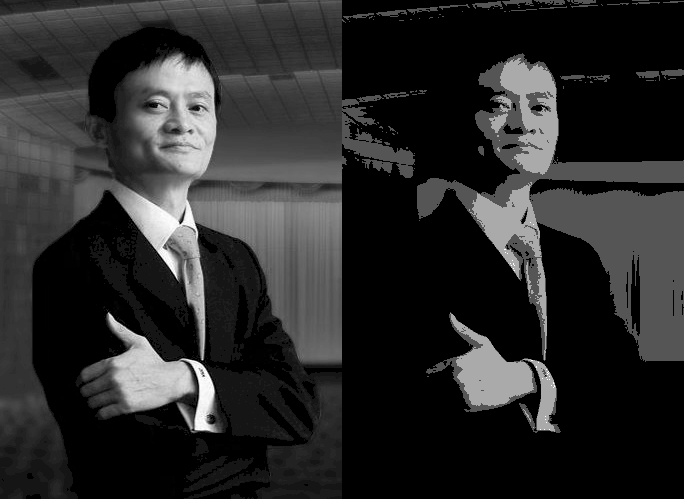

In [ ]:
import cv2 as cv
import numpy as np

print('Mengubah gambar berdasarkan bit depth')
print('-------------------------------------')

bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)

original = cv.imread('/content/drive/MyDrive/Bahan PCVK/man.png', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        depth_image[y, x] = np.clip((original[y, x] // level) * level, 0, 255)

final_frame = cv.hconcat((original, depth_image))
cv2_imshow(final_frame)

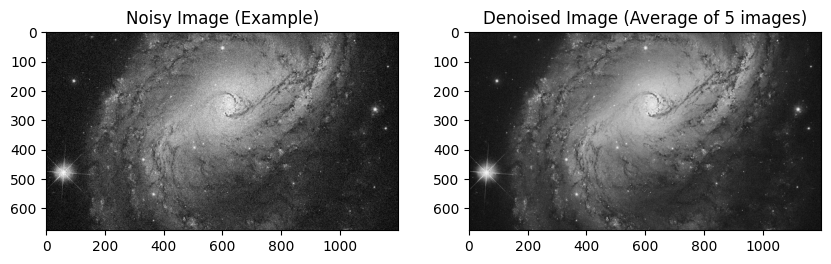

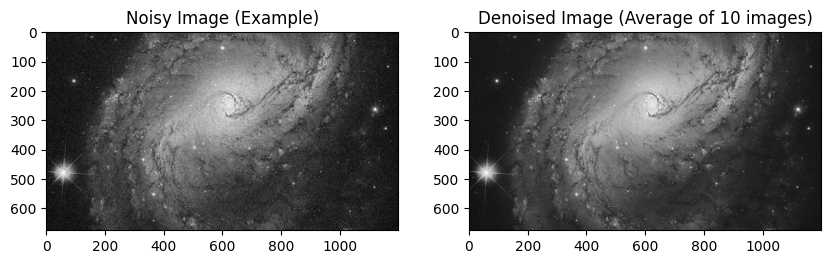

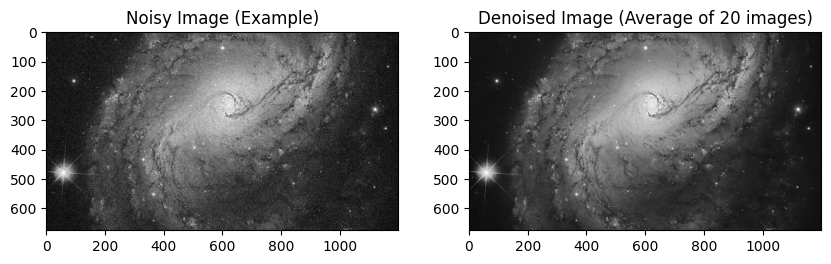

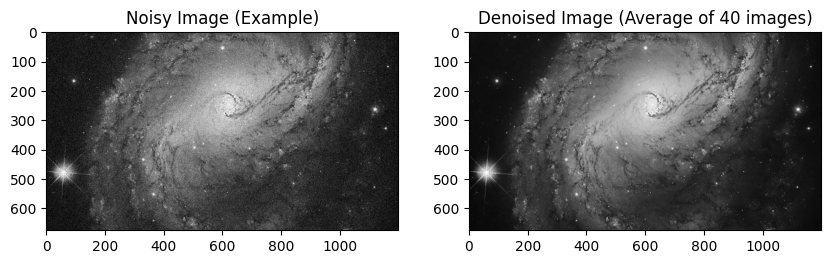

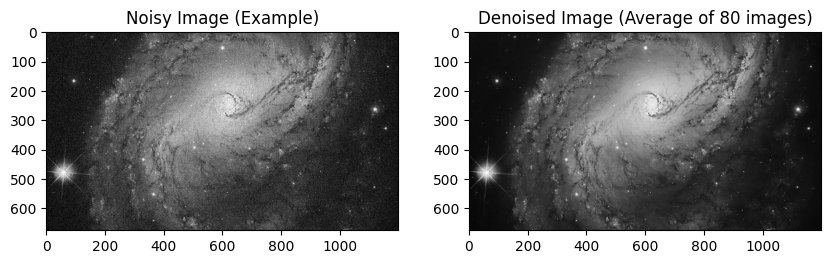

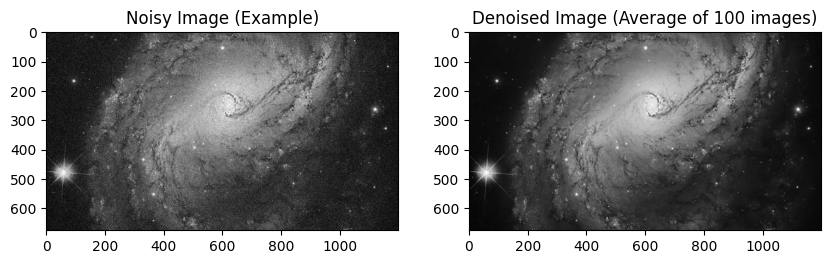

Number of averaged images: 5 - PSNR: 30.06 dB
Number of averaged images: 10 - PSNR: 31.46 dB
Number of averaged images: 20 - PSNR: 33.56 dB
Number of averaged images: 40 - PSNR: 36.21 dB
Number of averaged images: 80 - PSNR: 38.87 dB
Number of averaged images: 100 - PSNR: 39.69 dB


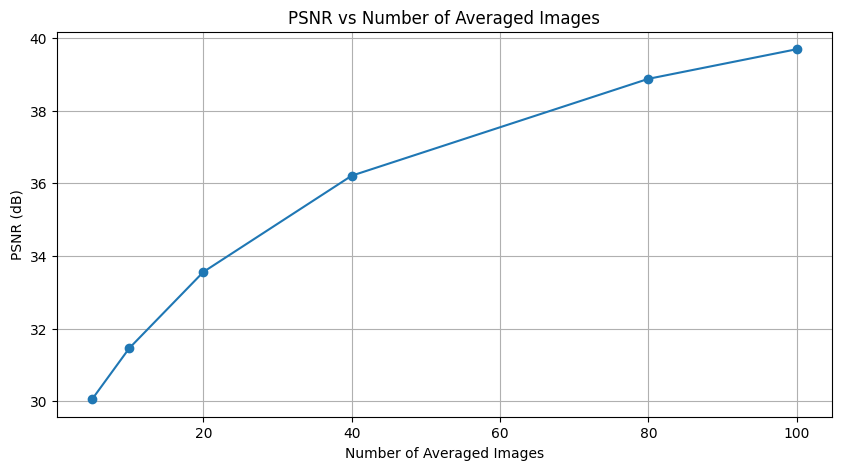

In [9]:
def calculate_psnr(original, denoised):
    mse = np.mean((original - denoised) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

def add_gaussian_noise(image, mean=0, sigma=25):
    gauss = np.random.normal(mean, sigma, image.shape)
    noisy = image + gauss
    return np.clip(noisy, 0, 255).astype(np.uint8)

original = cv2.imread('/content/drive/MyDrive/Bahan PCVK/galaxy.jpg', cv2.IMREAD_GRAYSCALE)

num_noisy_images = 100
noisy_images = [add_gaussian_noise(original) for _ in range(num_noisy_images)]

num_images_list = [5, 10, 20, 40, 80, 100]
psnr_values = []

for num_images in num_images_list:
    avg_image = np.mean(noisy_images[:num_images], axis=0).astype(np.uint8)

    psnr = calculate_psnr(original, avg_image)
    psnr_values.append(psnr)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(noisy_images[0], cmap='gray')
    plt.title('Noisy Image (Example)')
    plt.subplot(1, 2, 2)
    plt.imshow(avg_image, cmap='gray')
    plt.title(f'Denoised Image (Average of {num_images} images)')
    plt.show()

for i, num_images in enumerate(num_images_list):
    print(f"Number of averaged images: {num_images} - PSNR: {psnr_values[i]:.2f} dB")

plt.figure(figsize=(10, 5))
plt.plot(num_images_list, psnr_values, marker='o')
plt.title('PSNR vs Number of Averaged Images')
plt.xlabel('Number of Averaged Images')
plt.ylabel('PSNR (dB)')
plt.grid(True)
plt.show()

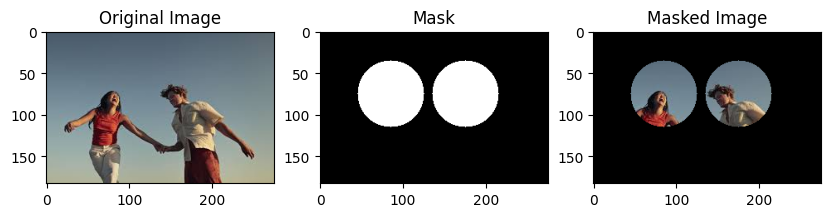

In [28]:
image = cv2.imread('/content/drive/MyDrive/Bahan PCVK/couple.jpg')

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

mask1 = np.zeros(image_rgb.shape[:2], dtype="uint8")
cv2.circle(mask1, (85, 75), 40, 255, -1)  # Posisi di wajah orang kiri

mask2 = np.zeros(image_rgb.shape[:2], dtype="uint8")
cv2.circle(mask2, (175, 75), 40, 255, -1)  # Posisi di wajah orang kanan

combined_mask = cv2.bitwise_or(mask1, mask2)

masked_image = cv2.bitwise_and(image_rgb, image_rgb, mask=combined_mask)

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_rgb)
plt.title('Original Image')

plt.subplot(1, 3, 2)
plt.imshow(combined_mask, cmap='gray')
plt.title('Mask')

plt.subplot(1, 3, 3)
plt.imshow(masked_image)
plt.title('Masked Image')
plt.show()


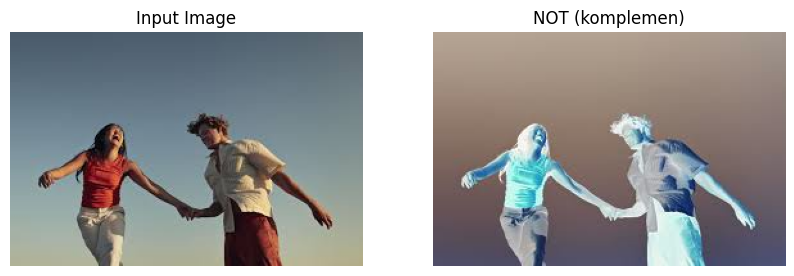

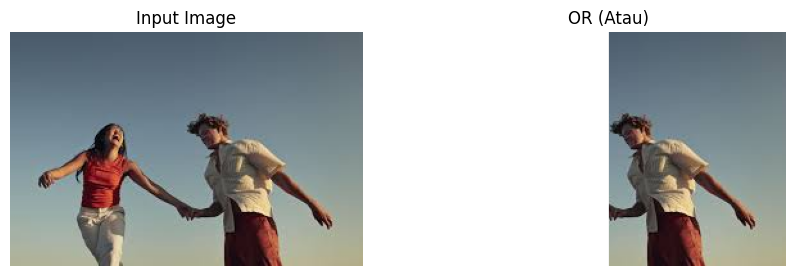

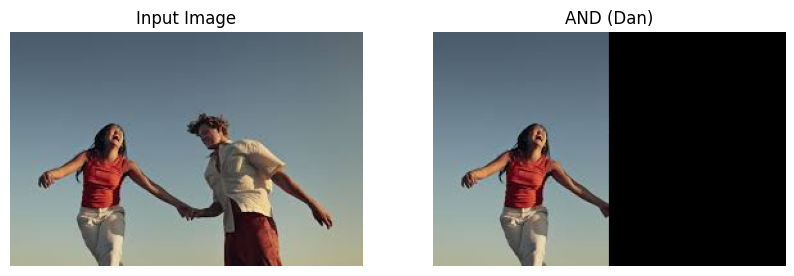

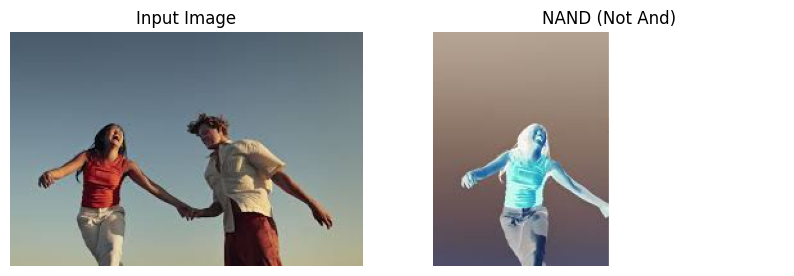

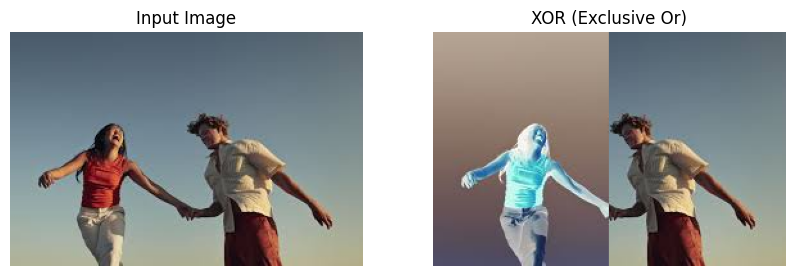

In [30]:
def show_images(title1, image1, title2, image2):
    plt.figure(figsize=(10,5))
    plt.subplot(121), plt.imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)), plt.title(title1), plt.axis('off')
    plt.subplot(122), plt.imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)), plt.title(title2), plt.axis('off')
    plt.show()

img = cv2.imread('/content/drive/MyDrive/Bahan PCVK/couple.jpg')

mask = np.zeros(img.shape, dtype=np.uint8)
mask[:, :img.shape[1]//2] = 255

not_img = cv2.bitwise_not(img)
or_img = cv2.bitwise_or(img, mask)
and_img = cv2.bitwise_and(img, mask)
nand_img = cv2.bitwise_not(cv2.bitwise_and(img, mask))
xor_img = cv2.bitwise_xor(img, mask)

show_images("Input Image", img, "NOT (komplemen)", not_img)
show_images("Input Image", img, "OR (Atau)", or_img)
show_images("Input Image", img, "AND (Dan)", and_img)
show_images("Input Image", img, "NAND (Not And)", nand_img)
show_images("Input Image", img, "XOR (Exclusive Or)", xor_img)